In [1]:
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20

# Initial the exp assay path variable
exp_anno_local = None

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_expAssays.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""exp_assays""","""scaled_fitness""","""#66BB6A""","""aPCA fitness""",1
"""exp_assays""","""DMS""","""#66BB6A""","""DMS""",-1
"""exp_assays""","""DMS_score_combined""","""#4DB6AC""","""DMS (combined)""",-1
"""exp_assays""","""LDL_uptake_functional""","""#66BB6A""","""LDL uptake functional""",-1
"""exp_assays""","""LDLR_cell_surface_abundance""","""#81C784""","""LDLR cell surface abundance""",-1
…,…,…,…,…
"""protein_domains""","""low_complexity_domain""","""#FF9933""","""Low Complexity Domain""",1
"""loftee_protein_domains""","""loftee_disorder""","""#E31A1C""","""Disordered Domain""",1
"""loftee_protein_domains""","""loftee_lip""","""#1E90FF""","""Linear Interacting Peptides""",1


In [3]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .unique(subset=["region"], keep="first", maintain_order=True)
)

gene_trait_df = (
    gene_trait_df
    .filter(
        pl.col('region') == 'ENSG00000130164',
        pl.col('phenotype') == 'ldl_direct_int',
    )
)

gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000130164""","""ldl_direct_int""",3.0392e-14,0.104534,0.104534,1.0


In [4]:
exp_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/experimental_assays"

# exp_anno_filename = "aPCA_Beltran_Nature_2025.parquet"
# exp_assay_score_columns = ['scaled_fitness']

# exp_anno_filename = "DMS_Marsh_VEP.parquet"
# exp_assay_score_columns = ['scaled_fitness']

# exp_anno_filename = "DMS_ProteinGym_substitutions.parquet"

exp_anno_filename = "LDLR_Roth_Science_2025.parquet"
exp_assay_type_column = 'assay'
exp_assay_score_column = 'score'

LOCAL_EXP_DIR = "/home/dnanexus/data_dir/experimental_assays"
!mkdir -p {LOCAL_EXP_DIR}
!dx download {exp_anno_path}/{exp_anno_filename} -o {LOCAL_EXP_DIR}

exp_anno_local = f'{LOCAL_EXP_DIR}/{exp_anno_filename}'

id_cols = ['ref_aa', 'aa_position', 'alt_aa', 'region']
exp_anno_df = (
    pl.read_parquet(exp_anno_local)
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .drop_nulls(subset=id_cols)
    # .select(id_cols + exp_assay_type_columns + exp_assay_score_columns)
    .pivot(
        index=id_cols,
        on=exp_assay_type_column,
        values=exp_assay_score_column
    )
)

exp_assay_columns = list(set(exp_anno_df.columns) - set(id_cols))

exp_assay_columns = ['LDL_uptake_functional', 'LDLR_cell_surface_abundance']
exp_anno_df = exp_anno_df.select(id_cols + exp_assay_columns)

exp_anno_df

Error: path
"/home/dnanexus/data_dir/experimental_assays/LDLR_Roth_Science_2025.parquet"
already exists but -f/--overwrite was not set


/tmp/ipykernel_217777/2925430958.py:24: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


ref_aa,aa_position,alt_aa,region,LDL_uptake_functional,LDLR_cell_surface_abundance
str,i64,str,str,f64,f64
"""G""",2,"""L""","""ENSG00000130164""",-0.042187,0.90099
"""G""",2,"""W""","""ENSG00000130164""",0.985631,1.012781
"""G""",2,"""A""","""ENSG00000130164""",0.964176,1.021534
"""G""",2,"""Y""","""ENSG00000130164""",-0.026747,1.062286
"""G""",2,"""M""","""ENSG00000130164""",1.012579,1.130779
…,…,…,…,…,…
"""G""",343,"""Q""","""ENSG00000130164""",null,null
"""A""",348,"""W""","""ENSG00000130164""",null,null
"""A""",348,"""Y""","""ENSG00000130164""",null,null


In [5]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_with_all_old.parquet"
ANNO_FILE = "annotations_with_all_no_dup.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# Join new annotation if specified above
if exp_anno_local is not None:
    anno = (
        anno
        .filter(
            pl.col('amino_acids').is_not_null(),
            pl.col('amino_acids').str.contains("/"),
            ~pl.col('protein_position').str.contains("-")
        )
        .with_columns(
            pl.col("amino_acids").str.split("/").list.get(0).alias("ref_aa"),
            pl.col("amino_acids").str.split("/").list.get(1).alias("alt_aa"),
            pl.col("protein_position").str.split("/").list.get(0).cast(pl.Int64).alias("aa_position")
        )

        .join(
            exp_anno_df.lazy(),
            on=['ref_aa', 'aa_position', 'alt_aa', 'region'],
            how='left'
        )

        # Restrict to variants with experimental assay data
        .drop_nulls(exp_assay_columns)
    )


anno = (
    anno
    .filter(
        # Filter to gene regions of interest
        (pl.col('region').is_in(gene_trait_df['region'].unique())),
        
        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True),
        # (pl.col('consequence_synonymous_variant') == True),

        # Filter for missense variants that we can merge with exp assay data
        # (pl.col('amino_acids').is_not_null()) & (pl.col('amino_acids').str.contains("/")) & (~pl.col('protein_position').str.contains("-")),

        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True),

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),
        
        # Choose MobiDB region
        # (pl.col('mobi_lip_full') == True),
        # (pl.col('mobi_disorder_full') == True),

        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)),

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    
)



selected_categories = ['missense', 'conservation'] # missense
# selected_categories = ['protein_domains'] # protein domains
# selected_categories = ['loftee_protein_domains'] # protein domains
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # synonymous
# selected_categories = ['plof', 'missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'] # CDS

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

selected_annos = list(set(selected_annos).intersection(set(existing_annos))) + exp_assay_columns
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

[===========================================================>] Completed 6,228,410,850 of 6,228,410,850 bytes (100%) /home/dnanexus/data_dir/annotations_with_all_no_dup.parquett


/tmp/ipykernel_217777/1351151775.py:81: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_217777/1351151775.py:91: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,LDL_uptake_functional,cpt1_llr,verphylop,am_pathogenicity,priphylop,polyphen,bayes_del,revel_score,esmscoremissense,LDLR_cell_surface_abundance,region,clinpred_score,gpn_score,mamphylop
str,f64,f32,f32,f32,f32,f32,f32,f32,f32,f64,str,f32,f32,f32
"""chr19:11105448:C:T""",0.99451,0.117906,1.696,0.1377,0.418,0.503,-0.088815,0.83,-6.727,0.946356,"""ENSG00000130164""",0.477882,-2.87,0.687
"""chr19:11105481:G:C""",0.849301,0.088208,-1.634,0.0997,-0.313,0.0,-0.362599,0.281,-3.261,1.1642258,"""ENSG00000130164""",0.027299,-1.29,-1.053
"""chr19:11105457:G:A""",0.063197,0.727056,10.978,0.9591,0.595,1.0,0.577649,0.854,-9.371,0.98831,"""ENSG00000130164""",0.999918,-9.98,4.19
"""chr19:11105538:A:C""",0.201113,0.231291,3.698,0.1283,0.475,0.989,0.014259,0.643,-7.445,1.012659,"""ENSG00000130164""",0.887688,-6.74,3.262
"""chr19:11105544:G:C""",0.785666,0.186451,2.321,0.1186,-0.191,0.029,0.131377,0.564,-5.462,0.249596,"""ENSG00000130164""",0.067102,-5.28,2.885
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr19:11107466:A:G""",0.79488,0.182205,-0.315,0.0967,-0.568,0.443,-0.138626,0.412,-4.959,1.096798,"""ENSG00000130164""",0.023523,-0.09,-0.101
"""chr19:11107398:T:G""",0.817529,0.077484,0.367,0.0702,-0.472,0.271,-0.106585,0.388,-4.352,0.868574,"""ENSG00000130164""",0.123488,-0.55,0.29
"""chr19:11107425:G:A""",0.033763,0.856353,11.148,0.9951,0.576,0.986,0.605046,0.929,-13.447,0.111815,"""ENSG00000130164""",0.999962,-9.42,4.331


In [6]:
melted_anno = (
    anno.lazy()

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
        
    # Keep variants that don't have fillna annotation
    # .join(
    #     anno_fillna_melted,
    #     on=['id', 'region', 'annotation'],
    #     how='semi'
    # )
    
    .collect(engine='streaming')
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr19:11105448:C:T""","""ENSG00000130164""","""cpt1_llr""",0.117906
"""chr19:11105481:G:C""","""ENSG00000130164""","""cpt1_llr""",0.088208
"""chr19:11105457:G:A""","""ENSG00000130164""","""cpt1_llr""",0.727056
"""chr19:11105538:A:C""","""ENSG00000130164""","""cpt1_llr""",0.231291
"""chr19:11105544:G:C""","""ENSG00000130164""","""cpt1_llr""",0.186451
…,…,…,…
"""chr19:11107466:A:G""","""ENSG00000130164""","""LDLR_cell_surface_abundance""",1.096798
"""chr19:11107398:T:G""","""ENSG00000130164""","""LDLR_cell_surface_abundance""",0.868574
"""chr19:11107425:G:A""","""ENSG00000130164""","""LDLR_cell_surface_abundance""",0.111815


In [7]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

# APPV_FILE = "loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet"
APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


In [8]:
from scipy.stats import spearmanr, norm

ci_alpha = 0.05
z_crit = norm.ppf(1 - ci_alpha / 2)  # 1.96 for 95% CI

# --- 1. Collect the pre-correlation data ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())

pre_corr_data = (
    appv
    .join(anno_ids_lazy, on="id", how="semi")
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_na' in c]),
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df["region", "phenotype"].lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .filter(pl.col('annotation') != 'loftee_hc')
    .collect(engine='streaming')
)

# --- 2. Spearman correlation with Fisher Z-transformation CI ---
results = []

for (region, phenotype, annotation), group in pre_corr_data.group_by(['region', 'phenotype', 'annotation']):
    scores = group['annotation_score'].to_numpy().astype(np.float64)
    pheno_vals = group['mean_pheno_value'].to_numpy().astype(np.float64)
    
    # Drop NaN pairs
    mask = ~(np.isnan(scores) | np.isnan(pheno_vals))
    scores, pheno_vals = scores[mask], pheno_vals[mask]
    n = len(scores)
    
    if n < 3 or len(np.unique(scores)) < 2 or len(np.unique(pheno_vals)) < 2:
        continue
    
    # Original correlation
    orig_corr, _ = spearmanr(scores, pheno_vals)
    
    # Fisher Z-transformation for CI
    z = np.arctanh(orig_corr)
    se_z = 1 / np.sqrt(n - 3)
    z_ci_low = z - z_crit * se_z
    z_ci_high = z + z_crit * se_z
    ci_low = np.tanh(z_ci_low)
    ci_high = np.tanh(z_ci_high)
    
    results.append({
        'region': region, 
        'phenotype': phenotype, 
        'annotation': annotation,
        'n_variants': n, 
        'correlation': orig_corr, 
        'ci_low': ci_low, 
        'ci_high': ci_high,
    })

final_lazy_plan = pl.DataFrame(results)

# --- 3. Join with beta directions and annotation directions ---
correlation_df = (
    final_lazy_plan
    .join(anno_config_df.drop('category').unique(), on='annotation')
    .join(gene_trait_df, on=['region', 'phenotype'])
    .with_columns(
        corr_beta = pl.col('correlation') * pl.col('loftee_corr_dir') * pl.col('annotation_dir'),
        ci_low_beta = pl.col('ci_low') * pl.col('loftee_corr_dir') * pl.col('annotation_dir'),
        ci_high_beta = pl.col('ci_high') * pl.col('loftee_corr_dir') * pl.col('annotation_dir'),
    )
    # When direction flips the sign, ci_low/ci_high swap — fix ordering
    .with_columns(
        ci_low_beta_final = pl.min_horizontal('ci_low_beta', 'ci_high_beta'),
        ci_high_beta_final = pl.max_horizontal('ci_low_beta', 'ci_high_beta'),
    )
    .drop(['ci_low_beta', 'ci_high_beta'])
    .rename({'ci_low_beta_final': 'ci_low_beta', 'ci_high_beta_final': 'ci_high_beta'})
)

print("Final DataFrame shape:", correlation_df.shape)
correlation_df

Final DataFrame shape: (13, 17)


region,phenotype,annotation,n_variants,correlation,ci_low,ci_high,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,ci_low_beta,ci_high_beta
str,str,str,i64,f64,f64,f64,str,str,i8,f64,f64,f64,f64,f64,f64,f64
"""ENSG00000130164""","""ldl_direct_int""","""gpn_score""",398,-0.224891,-0.316199,-0.129454,"""#807DBA""","""GPN-MSA""",-1,3.0392e-14,0.104534,0.104534,1.0,0.224891,0.129454,0.316199
"""ENSG00000130164""","""ldl_direct_int""","""clinpred_score""",398,0.199502,0.103228,0.292072,"""#FFDC80""","""ClinPred""",1,3.0392e-14,0.104534,0.104534,1.0,0.199502,0.103228,0.292072
"""ENSG00000130164""","""ldl_direct_int""","""polyphen""",398,0.195651,0.099262,0.288403,"""#FF90AA""","""PolyPhen2""",1,3.0392e-14,0.104534,0.104534,1.0,0.195651,0.099262,0.288403
"""ENSG00000130164""","""ldl_direct_int""","""revel_score""",398,0.194252,0.097822,0.287068,"""#FF7000""","""REVEL""",1,3.0392e-14,0.104534,0.104534,1.0,0.194252,0.097822,0.287068
"""ENSG00000130164""","""ldl_direct_int""","""cpt1_llr""",398,0.224822,0.129384,0.316134,"""#AF0000""","""CPT-1""",1,3.0392e-14,0.104534,0.104534,1.0,0.224822,0.129384,0.316134
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000130164""","""ldl_direct_int""","""esmscoremissense""",398,-0.197664,-0.290321,-0.101335,"""#CD853F""","""ESM1v""",-1,3.0392e-14,0.104534,0.104534,1.0,0.197664,0.101335,0.290321
"""ENSG00000130164""","""ldl_direct_int""","""priphylop""",398,0.05323,-0.045305,0.150739,"""#3F007D""","""Primate PhyloP""",1,3.0392e-14,0.104534,0.104534,1.0,0.05323,-0.045305,0.150739
"""ENSG00000130164""","""ldl_direct_int""","""LDLR_cell_surface_abundance""",398,-0.080643,-0.177534,0.017796,"""#81C784""","""LDLR cell surface abundance""",-1,3.0392e-14,0.104534,0.104534,1.0,0.080643,-0.017796,0.177534


In [9]:

consistent_gt = (
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['region', 'phenotype'])
    .agg(n_annotations = pl.len())
    .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

filt_corr_df = correlation_df.filter(pl.col("n_variants") > 10)
filt_corr_df = filt_corr_df.join(consistent_gt, on=['region', 'phenotype'], how='inner')
filt_corr_df

region,phenotype,annotation,n_variants,correlation,ci_low,ci_high,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,ci_low_beta,ci_high_beta,n_annotations
str,str,str,i64,f64,f64,f64,str,str,i8,f64,f64,f64,f64,f64,f64,f64,u64
"""ENSG00000130164""","""ldl_direct_int""","""gpn_score""",398,-0.224891,-0.316199,-0.129454,"""#807DBA""","""GPN-MSA""",-1,3.0392e-14,0.104534,0.104534,1.0,0.224891,0.129454,0.316199,13
"""ENSG00000130164""","""ldl_direct_int""","""clinpred_score""",398,0.199502,0.103228,0.292072,"""#FFDC80""","""ClinPred""",1,3.0392e-14,0.104534,0.104534,1.0,0.199502,0.103228,0.292072,13
"""ENSG00000130164""","""ldl_direct_int""","""polyphen""",398,0.195651,0.099262,0.288403,"""#FF90AA""","""PolyPhen2""",1,3.0392e-14,0.104534,0.104534,1.0,0.195651,0.099262,0.288403,13
"""ENSG00000130164""","""ldl_direct_int""","""revel_score""",398,0.194252,0.097822,0.287068,"""#FF7000""","""REVEL""",1,3.0392e-14,0.104534,0.104534,1.0,0.194252,0.097822,0.287068,13
"""ENSG00000130164""","""ldl_direct_int""","""cpt1_llr""",398,0.224822,0.129384,0.316134,"""#AF0000""","""CPT-1""",1,3.0392e-14,0.104534,0.104534,1.0,0.224822,0.129384,0.316134,13
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000130164""","""ldl_direct_int""","""esmscoremissense""",398,-0.197664,-0.290321,-0.101335,"""#CD853F""","""ESM1v""",-1,3.0392e-14,0.104534,0.104534,1.0,0.197664,0.101335,0.290321,13
"""ENSG00000130164""","""ldl_direct_int""","""priphylop""",398,0.05323,-0.045305,0.150739,"""#3F007D""","""Primate PhyloP""",1,3.0392e-14,0.104534,0.104534,1.0,0.05323,-0.045305,0.150739,13
"""ENSG00000130164""","""ldl_direct_int""","""LDLR_cell_surface_abundance""",398,-0.080643,-0.177534,0.017796,"""#81C784""","""LDLR cell surface abundance""",-1,3.0392e-14,0.104534,0.104534,1.0,0.080643,-0.017796,0.177534,13


In [10]:
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


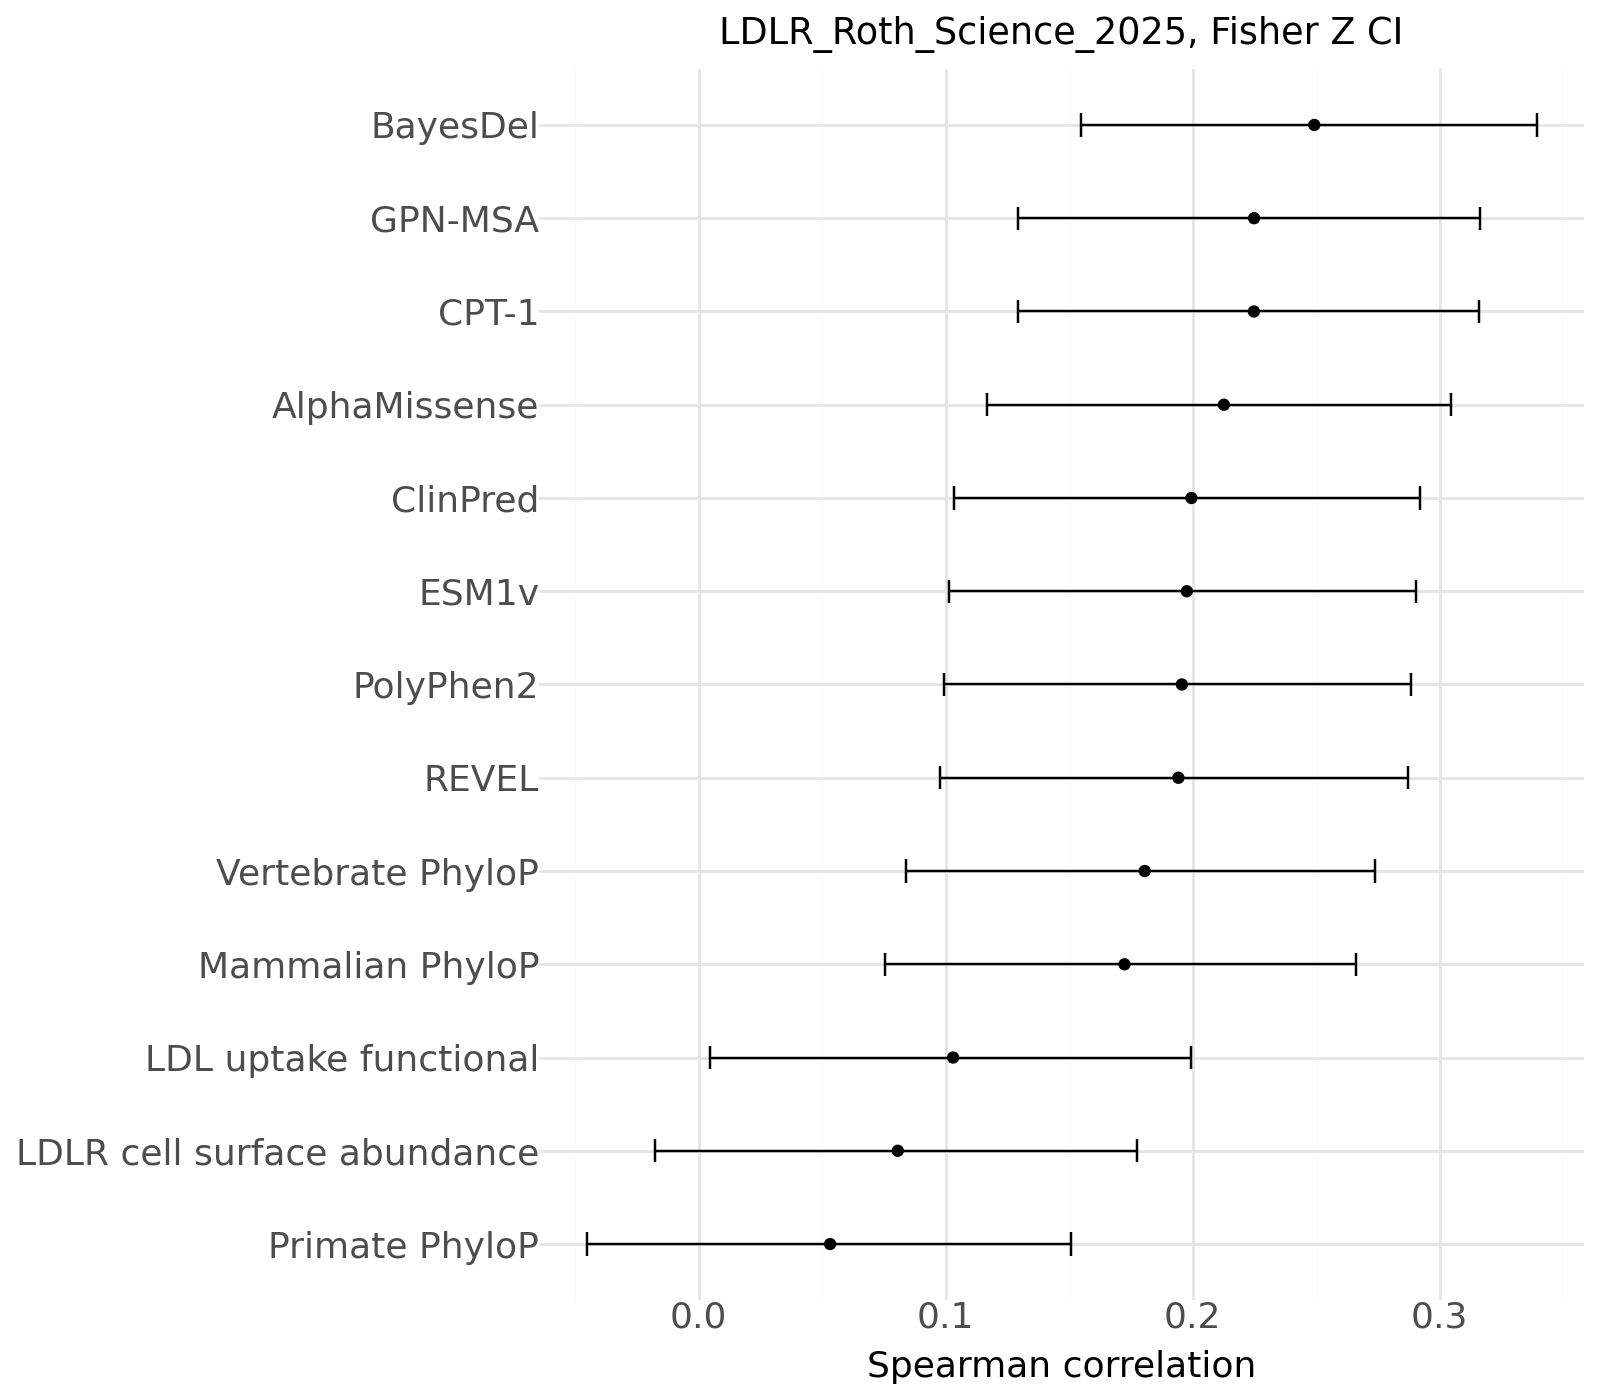

In [11]:
plotting_col = 'corr_beta'
dashed_line_value = 1 if 'rescaled' in plotting_col else 0

# Calculate medians and join back
corr_pl = (
    filt_corr_df
    .drop_nans()
    .with_columns(
        median_corr_beta = pl.col(plotting_col).median().over("annotation")
    )
)

# 2. Determine the categorical order for the labels
ordered_labels = (
    corr_pl
    .sort("median_corr_beta", descending=False)
    .select("label")
    .unique(maintain_order=True)
    .to_series()
)

# 3. Apply the ordering using pl.Enum
corr_pl = corr_pl.with_columns(pl.col("label").cast(pl.Enum(ordered_labels)))

# 4. Create the color dictionary (Polars style)
color_dict = dict(corr_pl.select("annotation", "color").unique().iter_rows())

# Plot
(
    ggplot(corr_pl, aes(x="label", y=plotting_col))
    # + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    + geom_point(size=1.5)
    + geom_errorbar(aes(ymin="ci_low_beta", ymax="ci_high_beta"), width=0.25)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{exp_anno_filename.replace('.parquet', '')}, Fisher Z CI"
    )
    + coord_flip()
    + theme(
        figure_size=(8, corr_pl['annotation'].n_unique()/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

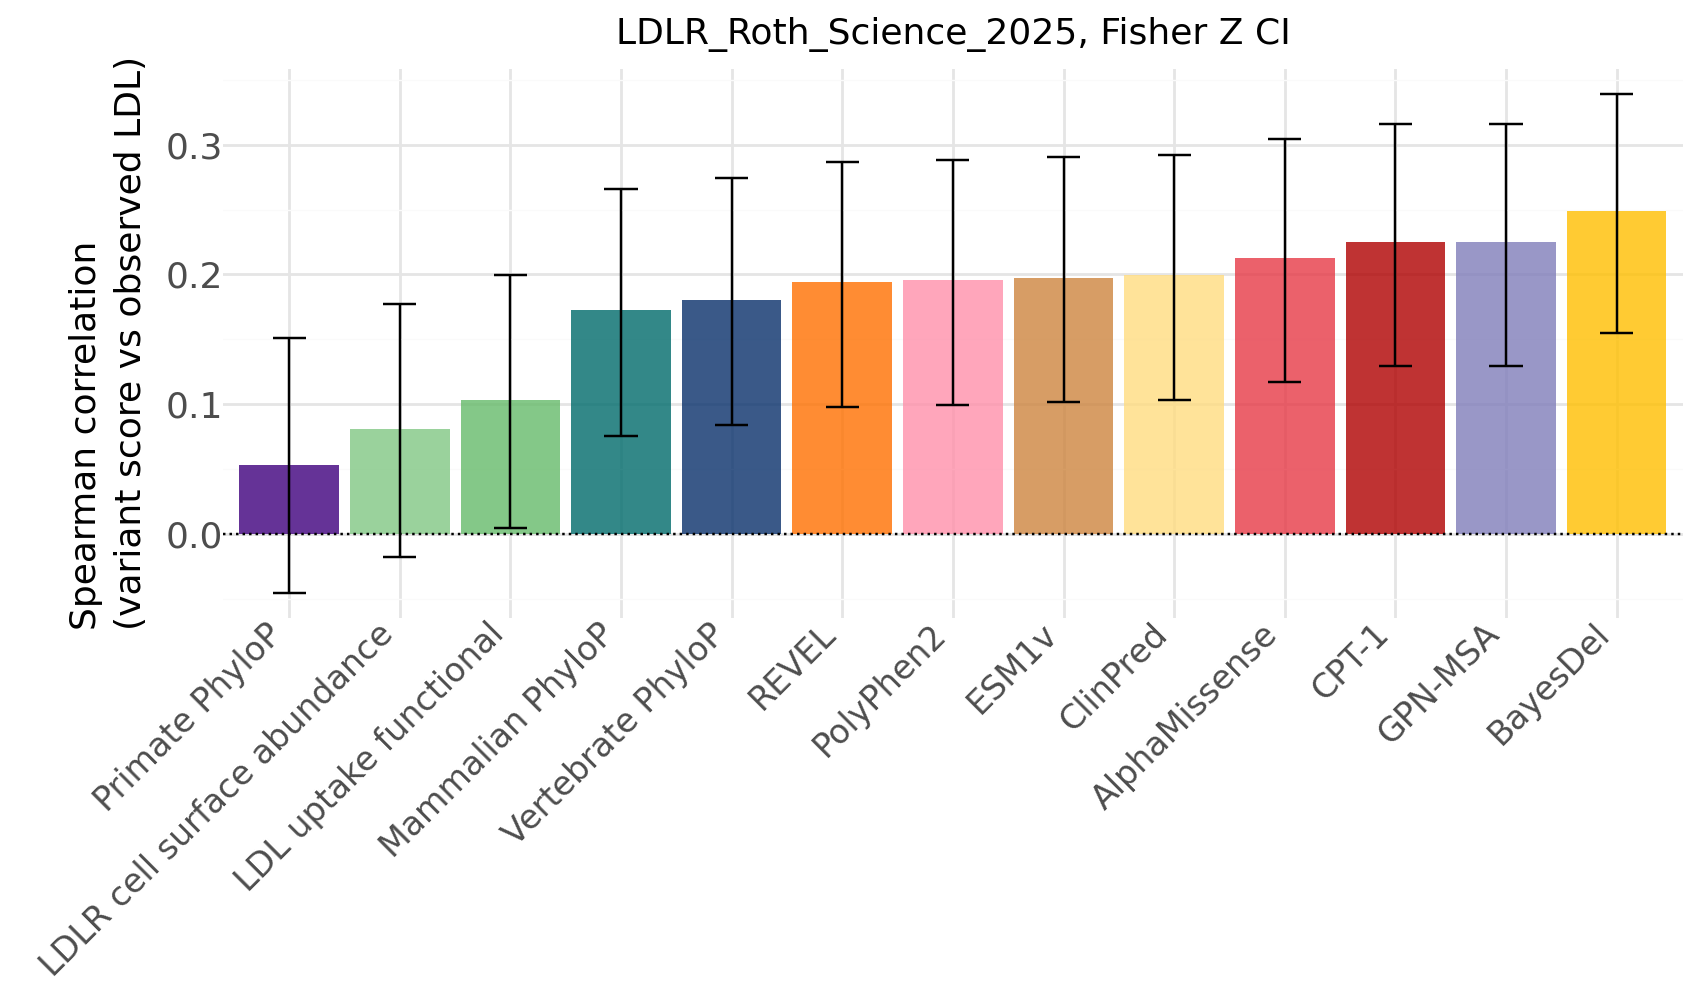

In [12]:
# Vertical bar plot with colored bars and CI error bars
color_dict_label = dict(corr_pl.select("label", "color").unique().iter_rows())

(
    ggplot(corr_pl, aes(x="label", y=plotting_col, fill="label"))
    + geom_col(alpha=0.8)
    + geom_errorbar(aes(ymin="ci_low_beta", ymax="ci_high_beta"), width=0.3, size=0.5)
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    + scale_fill_manual(values=color_dict_label)
    + labs(
        x="",
        y="Spearman correlation\n(variant score vs observed LDL)",
        title=f"{exp_anno_filename.replace('.parquet', '')}, Fisher Z CI"
    )
    + theme_minimal()
    + theme(
        figure_size=(corr_pl['annotation'].n_unique()/2 + 2, 5),
        legend_position="none",
        axis_text_x=element_text(size=12, rotation=45, ha='right'),
        axis_text_y=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [13]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "phenotype", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "phenotype", "corr_beta"])

    merged = df_a.join(df_b, on=["region", "phenotype"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_217777/1012804157.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
